# Project 2

## Part 2 Advection Equation

In [2]:
# load all necessary libraries
import numpy as np
import matplotlib.pyplot as plt 
from scipy.linalg import solve

In [3]:
# define all the constant parameters
a = 300 # m/s
dx = 5
L = 300
xstep = int(L/dx)
# x in [0, 300]
x = np.linspace(0, L, xstep+1)
T = 0.5

In [4]:
# define the initial condition
def initial(x):
    u0 = np.where((x<110) & (x>=50), 100*np.sin(np.pi*((x-50)/60)), 0)
    return u0

In [5]:
# define the exact solution
def exact_sol(x, t):
    return initial(x - a * t)

In [6]:
#calculate errors over time
def calculate_errors(result, x, tstep, dt, dx):

    L2_inf = np.zeros(tstep)
    L2_error = np.zeros(tstep)

    for t in range(tstep):
        L2_inf[t] = np.max(np.abs(result[t,:] - exact_sol(x,t*dt)))
        L2_error[t] = np.sqrt(np.sum(np.abs(result[t,:] - exact_sol(x,t*dt))**2)*dx)
    
    return L2_inf, L2_error

### First Upwind Differencing Method

In [7]:
# define the method
def upwind(u0, c, tstep):
    u = np.zeros((tstep, len(x)))
    u[0, :] = u0
    for t in range (tstep -1):
        u[t+1, 1:-1] = u[t, 1:-1] - c* (u[t, 1:-1] - u[t, :-2])
        # boundary conditions
        u[t+1, 0] = 0
        u[t+1, -1] = 0

    return u

#### $\Delta t = 0.021$

Courrant number for dt = 0.021:  1.2600000000000002


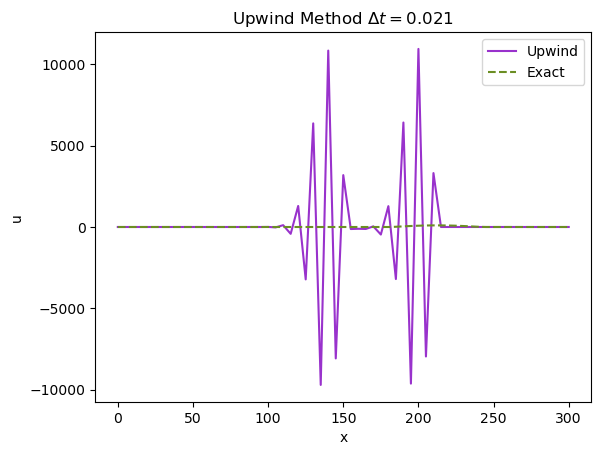

In [8]:
# changing parameters 
dt = 0.021
c = (a * dt) / dx
print("Courrant number for dt = 0.021: ", c)
tstep = int(T/dt) +1
t_target = 0.45
times = np.arange(tstep) * dt
idx = np.argmin(np.abs(times - t_target))
u0 = initial(x)
exact = exact_sol(x, times[idx])
# apply method
result1 = upwind(u0, c, tstep)
#plot results compared to exact sol.
plt.plot(x, result1[idx, :], color = 'darkorchid', label='Upwind')
plt.plot(x, exact, '--', color = "olivedrab", label='Exact')
plt.title(r'Upwind Method $\Delta t = 0.021$')
plt.xlabel('x')
plt.ylabel('u')
plt.legend()
plt.savefig('upwind1.png')
plt.show()

L_inf error: 23081.19884696833
L2 error:  131126.46917057587


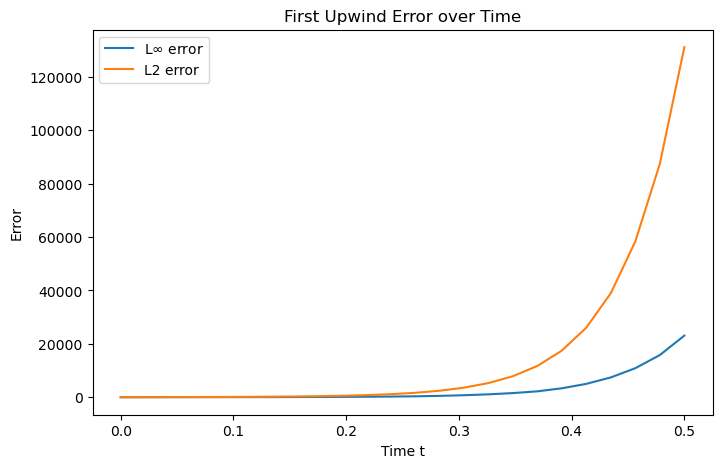

In [9]:
#use the function defined above to calculate the error
L2_inf, L2_error = calculate_errors(result1, x, tstep, dt, dx)
print("L_inf error:", L2_inf[-1])
print("L2 error: ", L2_error[-1])
#plot error over time
plt.figure(figsize=(8,5))
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_inf, label='L$\infty$ error')
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_error, label='L2 error')
plt.xlabel('Time t')
plt.ylabel('Error')
plt.title('First Upwind Error over Time')
plt.legend()
plt.savefig('Upwind_error1.png')
plt.show()

#### $\Delta t = 0.0166$

Courrant number for dt = 0.0166:  0.9960000000000001


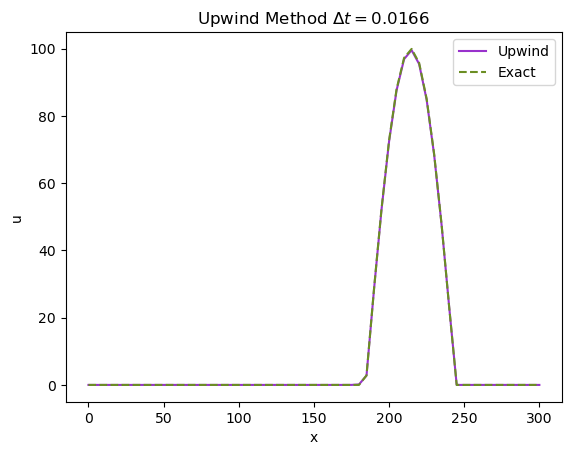

In [10]:
# changing parameters 
dt = 0.0166
c = (a * dt) / dx
print("Courrant number for dt = 0.0166: ", c)
tstep = int(T/dt) +1
t_target = 0.45
times = np.arange(tstep) * dt
idx = np.argmin(np.abs(times - t_target))
u0 = initial(x)
exact = exact_sol(x, times[idx])
# apply method
result2 = upwind(u0, c, tstep)
#plot results compared to exact sol.
plt.plot(x, result2[idx, :], color='darkorchid', label='Upwind')
plt.plot(x, exact, '--', color='olivedrab', label='Exact')
plt.title(r'Upwind Method $\Delta t = 0.0166$')
plt.xlabel('x')
plt.ylabel('u')
plt.legend()
plt.savefig('upwind2.png')
plt.show()

L_inf error: 0.4051814782450691
L2 error:  2.276450522380361


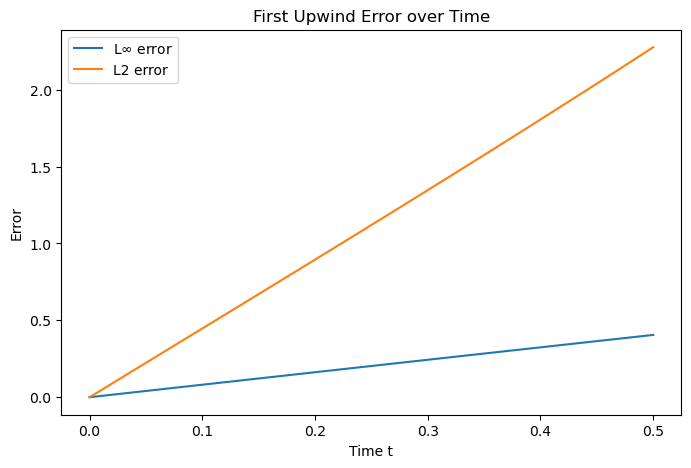

In [11]:
#use the function defined above to calculate the error
L2_inf, L2_error = calculate_errors(result2, x, tstep, dt, dx)
print("L_inf error:", L2_inf[-1])
print("L2 error: ", L2_error[-1])
#plot error over time
plt.figure(figsize=(8,5))
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_inf, label='L$\infty$ error')
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_error, label='L2 error')
plt.xlabel('Time t')
plt.ylabel('Error')
plt.title('First Upwind Error over Time')
plt.legend()
plt.savefig('Upwind_error2.png')
plt.show()

#### $\Delta t = 0.0075$

Courrant number for dt = 0.0075:  0.45


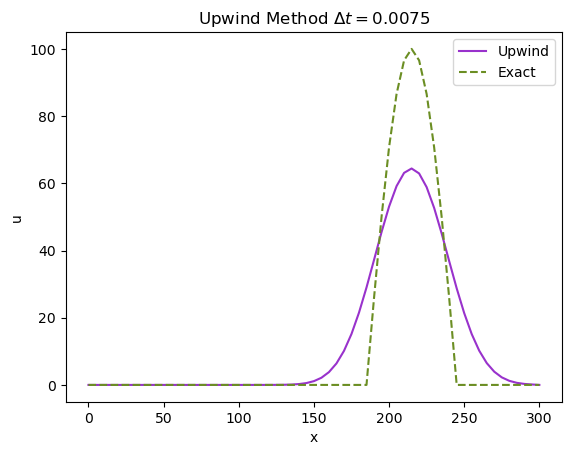

In [12]:
# changing parameters 
dt = 0.0075
c = (a * dt) / dx
print("Courrant number for dt = 0.0075: ", c)
tstep = int(T/dt) +1
t_target = 0.45
times = np.arange(tstep) * dt
idx = np.argmin(np.abs(times - t_target))
u0 = initial(x)
exact = exact_sol(x, times[idx])
# apply method
result3 = upwind(u0, c, tstep)
#plot results compared to exact sol.
plt.plot(x, result3[idx, :], color = 'darkorchid', label='Upwind')
plt.plot(x, exact, '--', color = "olivedrab", label='Exact')
plt.title(r'Upwind Method $\Delta t = 0.0075$')
plt.xlabel('x')
plt.ylabel('u')
plt.legend()
plt.savefig('upwind3.png')
plt.show()

L_inf error: 37.42099589035419
L2 error:  223.21591596549672


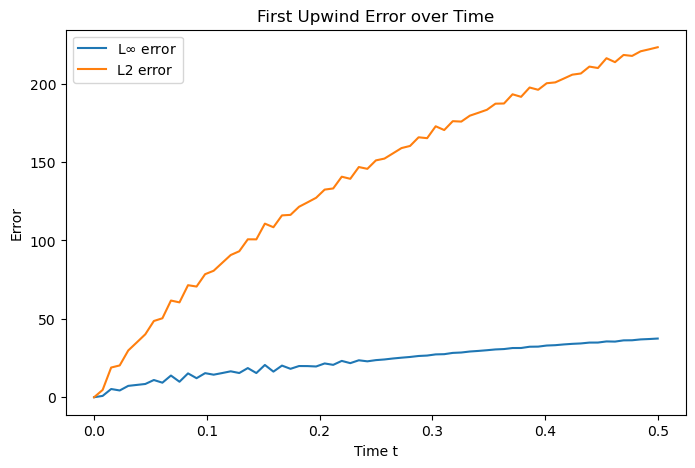

In [13]:
#use the function defined above to calculate the error
L2_inf, L2_error = calculate_errors(result3, x, tstep, dt, dx)
print("L_inf error:", L2_inf[-1])
print("L2 error: ", L2_error[-1])
#plot error over time
plt.figure(figsize=(8,5))
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_inf, label='L$\infty$ error')
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_error, label='L2 error')
plt.xlabel('Time t')
plt.ylabel('Error')
plt.title('First Upwind Error over Time')
plt.legend()
plt.savefig('Upwind_error3.png')
plt.show()

## Lax-Wendroff Method

In [14]:
# define the method
def lax(u0, c, tstep):
    u = np.zeros((tstep, len(x)))
    u[0, :] = u0
    for t in range (tstep-1):
        u[t+1, 1:-1] = u[t, 1:-1] - (c/2) * (u[t, 2:] - u[t, :-2]) + ((c**2) /2) * (u[t, :-2] - 2* u[t, 1:-1] + u[t, 2:])
        # boundary conditions
        u[t+1, 0] = 0
        u[t+1, -1] = 0
    return u

#### $\Delta t = 0.021$

Courrant number for dt = 0.021:  1.2600000000000002


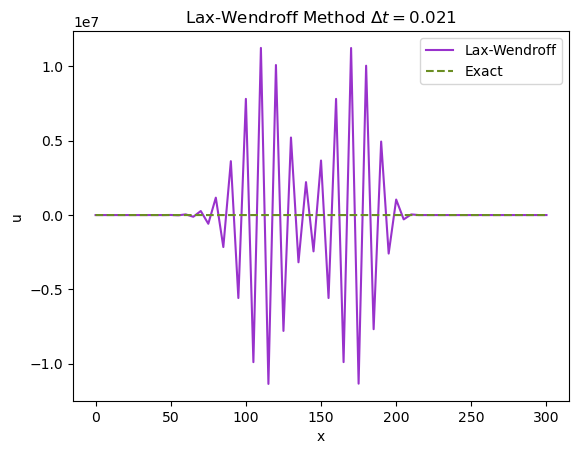

In [15]:
# changing parameters 
dt = 0.021
c = (a * dt) / dx
print("Courrant number for dt = 0.021: ", c)
tstep = int(T/dt) +1
t_target = 0.45
times = np.arange(tstep) * dt
idx = np.argmin(np.abs(times - t_target))
u0 = initial(x)
exact = exact_sol(x, times[idx])
# apply method
result4 = lax(u0, c, tstep)
#plot results compared to exact sol.
plt.plot(x, result4[idx, :], color = 'darkorchid', label='Lax-Wendroff')
plt.plot(x, exact, '--', color = "olivedrab", label='Exact')
plt.title(r'Lax-Wendroff Method $\Delta t = 0.021$')
plt.xlabel('x')
plt.ylabel('u')
plt.legend()
plt.savefig('lax1.png')
plt.show()

L_inf error: 51640571.65500726
L2 error:  377151283.46262157


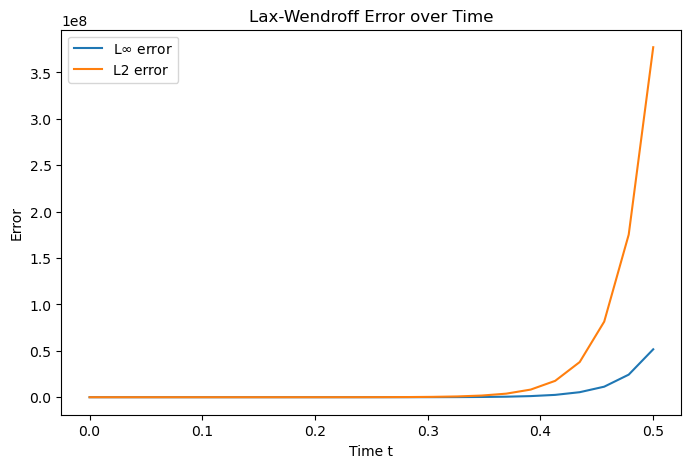

In [16]:
#use the function defined above to calculate the error
L2_inf, L2_error = calculate_errors(result4, x, tstep, dt, dx)
print("L_inf error:", L2_inf[-1])
print("L2 error: ", L2_error[-1])
#plot error over time
plt.figure(figsize=(8,5))
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_inf, label='L$\infty$ error')
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_error, label='L2 error')
plt.xlabel('Time t')
plt.ylabel('Error')
plt.title('Lax-Wendroff Error over Time')
plt.legend()
plt.savefig('lax_error1.png')
plt.show()

#### $\Delta t = 0.0166$

Courrant number for dt = 0.0166:  0.9960000000000001


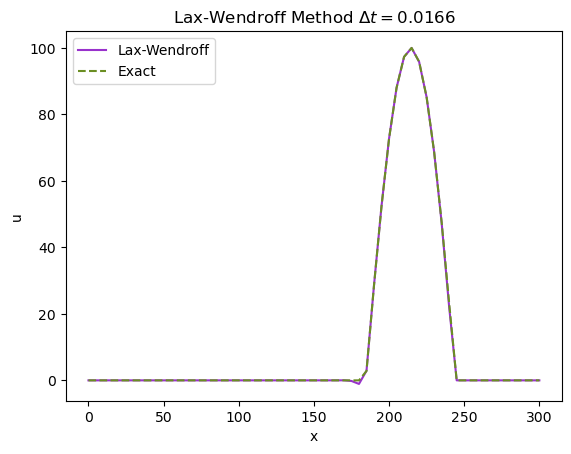

In [17]:
# changing parameters 
dt = 0.0166
c = (a * dt) / dx
print("Courrant number for dt = 0.0166: ", c)
tstep = int(T/dt) +1
t_target = 0.45
times = np.arange(tstep) * dt
idx = np.argmin(np.abs(times - t_target))
u0 = initial(x)
exact = exact_sol(x, times[idx])
# apply method
result5 = lax(u0, c, tstep)
#plot results compared to exact sol.
plt.plot(x, result5[idx, :], color = 'darkorchid', label='Lax-Wendroff')
plt.plot(x, exact, '--', color = "olivedrab", label='Exact')
plt.title(r'Lax-Wendroff Method $\Delta t = 0.0166$')
plt.xlabel('x')
plt.ylabel('u')
plt.legend()
plt.savefig('lax2.png')
plt.show()

L_inf error: 1.2232033062740157
L2 error:  3.8617168693166537


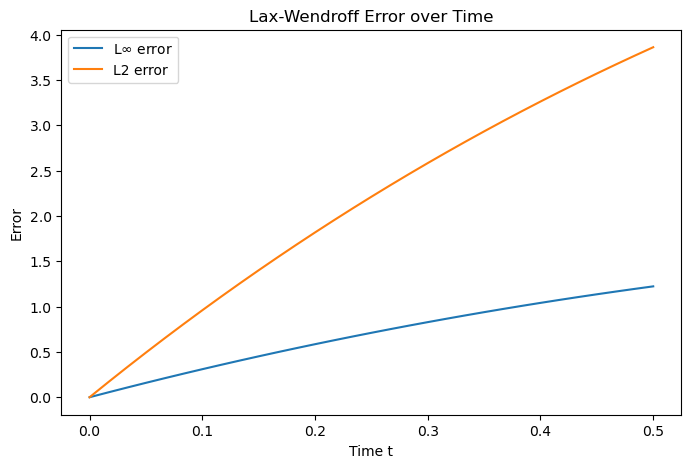

In [18]:
#use the function defined above to calculate the error
L2_inf, L2_error = calculate_errors(result5, x, tstep, dt, dx)
print("L_inf error:", L2_inf[-1])
print("L2 error: ", L2_error[-1])
#plot error over time
plt.figure(figsize=(8,5))
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_inf, label='L$\infty$ error')
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_error, label='L2 error')
plt.xlabel('Time t')
plt.ylabel('Error')
plt.title('Lax-Wendroff Error over Time')
plt.legend()
plt.savefig('lax_error2.png')
plt.show()

#### $\Delta t = 0.0075$

Courrant number for dt = 0.0075:  0.45


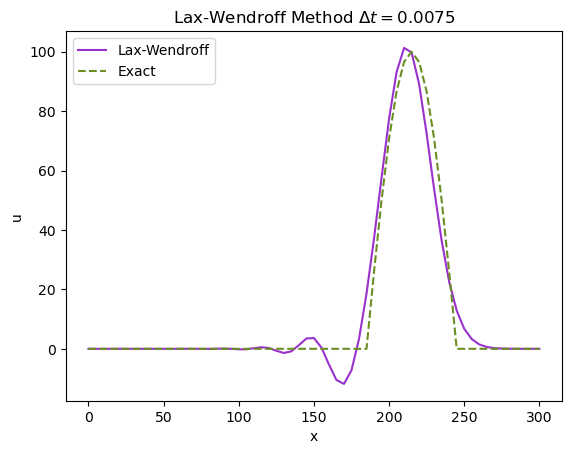

In [19]:
# changing parameters 
dt = 0.0075
c = (a * dt) / dx
print("Courrant number for dt = 0.0075: ", c)
tstep = int(T/dt) +1
t_target = 0.45
times = np.arange(tstep) * dt
idx = np.argmin(np.abs(times - t_target))
u0 = initial(x)
exact = exact_sol(x, times[idx])
# apply method
result6 = lax(u0, c, tstep)
#plot results compared to exact sol.
plt.plot(x, result6[idx, :], color = 'darkorchid', label='Lax-Wendroff')
plt.plot(x, exact, '--', color = "olivedrab", label='Exact')
plt.title(r'Lax-Wendroff Method $\Delta t = 0.0075$')
plt.xlabel('x')
plt.ylabel('u')
plt.legend()
plt.savefig('lax3.png')
plt.show()

L_inf error: 17.38074410842127
L2 error:  101.27306587000275


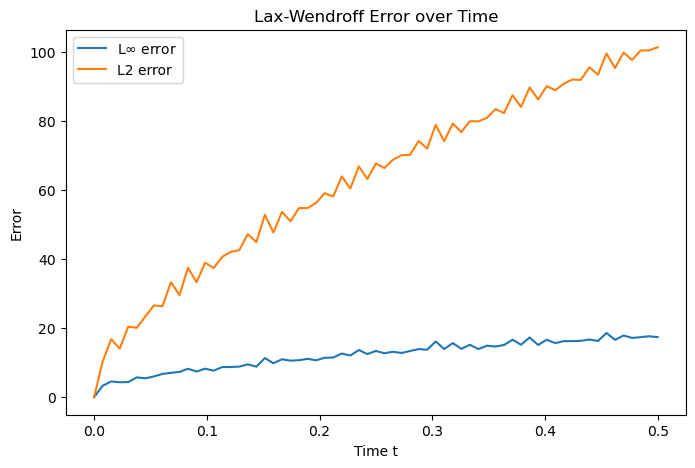

In [20]:
#use the function defined above to calculate the error
L2_inf, L2_error = calculate_errors(result6, x, tstep, dt, dx)
print("L_inf error:", L2_inf[-1])
print("L2 error: ", L2_error[-1])
#plot error over time
plt.figure(figsize=(8,5))
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_inf, label='L$\infty$ error')
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_error, label='L2 error')
plt.xlabel('Time t')
plt.ylabel('Error')
plt.title('Lax-Wendroff Error over Time')
plt.legend()
plt.savefig('lax_error3.png')
plt.show()

### Exact solution

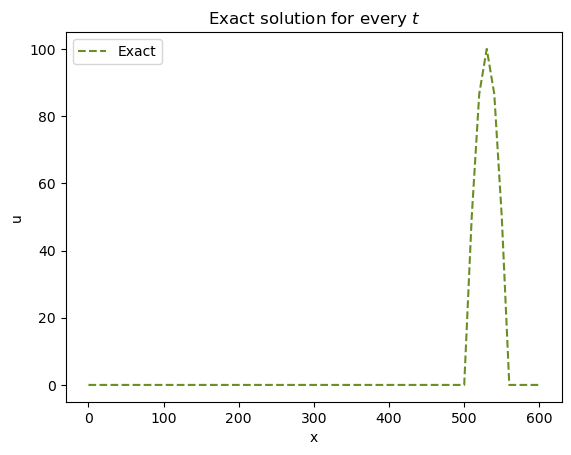

In [21]:
x2 =np.linspace(0, 600, xstep+1)
exact = exact_sol(x2, 1.5)
plt.plot(x2, exact, '--', color = "olivedrab", label='Exact')
plt.title(r'Exact solution for every $t$')
plt.xlabel('x')
plt.ylabel('u')
plt.legend()
plt.savefig('exact.png')
plt.show()

## Euler BTCS Method

In [22]:
# define method
def btcs(u0, c, tstep):
    Nx = len(u0)
    u  = np.zeros((tstep, Nx))
    u[0, :] = u0

    N = Nx -2
    A = np.eye(N) + np.diag(-(c/2) * np.ones(N-1), k=-1) + np.diag((c/2) * np.ones(N-1), k=1) 
    
    for time in range(tstep - 1):
        u_prev = u[time, 1:-1].copy()
        u[time+1, 1:-1] = solve(A, u_prev)
    
    return u
        

#### $\Delta t = 0.021$

Courrant number for dt = 0.021:  1.2600000000000002


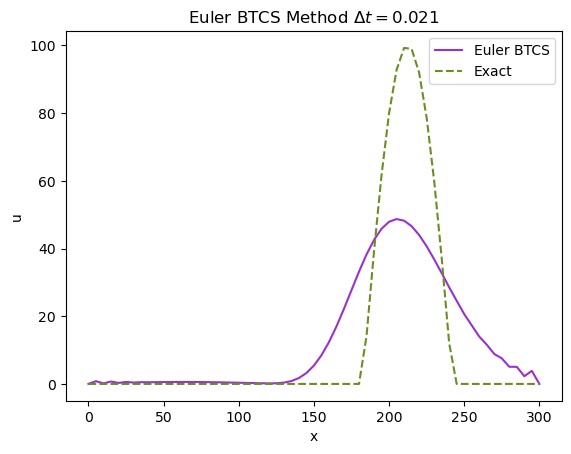

In [23]:
# changing parameters 
dt = 0.021
c = (a * dt) / dx
print("Courrant number for dt = 0.021: ", c)
tstep = int(T/dt) +1
t_target = 0.45
times = np.arange(tstep) * dt
idx = np.argmin(np.abs(times - t_target))
u0 = initial(x)
exact = exact_sol(x, times[idx])
# apply method
result7 = btcs(u0, c, tstep)
#plot results compared to exact sol.
plt.plot(x, result7[idx, :], color = 'darkorchid', label='Euler BTCS')
plt.plot(x, exact, '--', color = "olivedrab", label='Exact')
plt.title(r'Euler BTCS Method $\Delta t = 0.021$')
plt.xlabel('x')
plt.ylabel('u')
plt.legend()
plt.savefig('btcs1.png')
plt.show()

L_inf error: 54.16295219711021
L2 error:  317.0227306437093


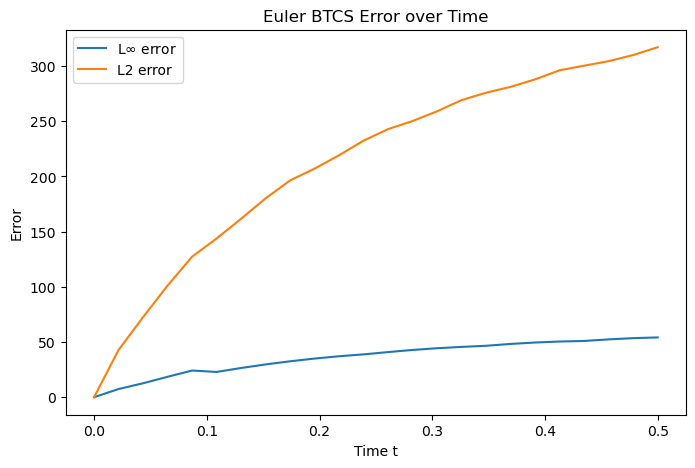

In [24]:
#use the function defined above to calculate the error
L2_inf, L2_error = calculate_errors(result7, x, tstep, dt, dx)
print("L_inf error:", L2_inf[-1])
print("L2 error: ", L2_error[-1])
#plot error over time
plt.figure(figsize=(8,5))
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_inf, label='L$\infty$ error')
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_error, label='L2 error')
plt.xlabel('Time t')
plt.ylabel('Error')
plt.title('Euler BTCS Error over Time')
plt.legend()
plt.savefig('btcs_error1.png')
plt.show()

#### $\Delta t = 0.0166$

Courrant number for dt = 0.0166:  0.9960000000000001


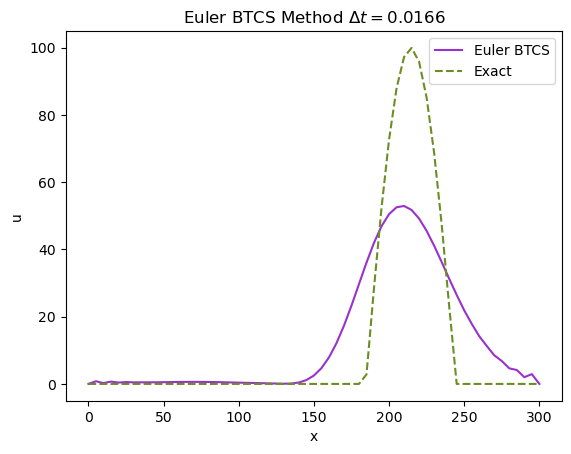

In [25]:
# changing parameters 
dt = 0.0166
c = (a * dt) / dx
print("Courrant number for dt = 0.0166: ", c)
tstep = int(T/dt) +1
t_target = 0.45
times = np.arange(tstep) * dt
idx = np.argmin(np.abs(times - t_target))
u0 = initial(x)
exact = exact_sol(x, times[idx])
# apply method
result8 = btcs(u0, c, tstep)
#plot results compared to exact sol.
plt.plot(x, result8[idx, :], color = 'darkorchid', label='Euler BTCS')
plt.plot(x, exact, '--', color = "olivedrab", label='Exact')
plt.title(r'Euler BTCS Method $\Delta t = 0.0166$')
plt.xlabel('x')
plt.ylabel('u')
plt.legend()
plt.savefig('btcs2.png')
plt.show()

L_inf error: 50.39385656619354
L2 error:  294.4553584220713


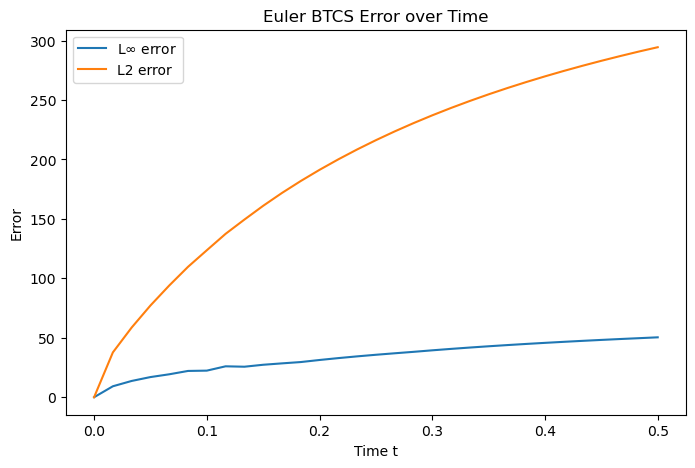

In [26]:
#use the function defined above to calculate the error
L2_inf, L2_error = calculate_errors(result8, x, tstep, dt, dx)
print("L_inf error:", L2_inf[-1])
print("L2 error: ", L2_error[-1])
#plot error over time
plt.figure(figsize=(8,5))
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_inf, label='L$\infty$ error')
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_error, label='L2 error')
plt.xlabel('Time t')
plt.ylabel('Error')
plt.title('Euler BTCS Error over Time')
plt.legend()
plt.savefig('btcs_error2.png')
plt.show()

#### $\Delta t = 0.0075$

Courrant number for dt = 0.0075:  0.45


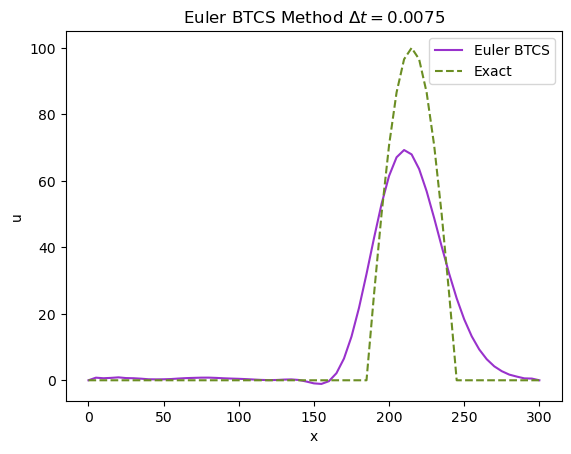

In [27]:
# changing parameters 
dt = 0.0075
c = (a * dt) / dx
print("Courrant number for dt = 0.0075: ", c)
tstep = int(T/dt) +1
t_target = 0.45
times = np.arange(tstep) * dt
idx = np.argmin(np.abs(times - t_target))
u0 = initial(x)
exact = exact_sol(x, times[idx])
# apply method
result9 = btcs(u0, c, tstep)
#plot results compared to exact sol.
plt.plot(x, result9[idx, :], color = 'darkorchid', label='Euler BTCS')
plt.plot(x, exact, '--', color = "olivedrab", label='Exact')
plt.title(r'Euler BTCS Method $\Delta t = 0.0075$')
plt.xlabel('x')
plt.ylabel('u')
plt.legend()
plt.savefig('btcs3.png')
plt.show()

L_inf error: 34.77853428577056
L2 error:  208.31911618791182


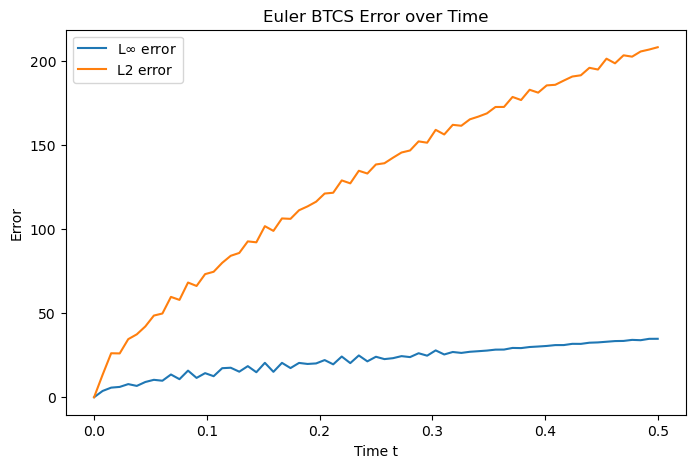

In [28]:
#use the function defined above to calculate the error
L2_inf, L2_error = calculate_errors(result9, x, tstep, dt, dx)
print("L_inf error:", L2_inf[-1])
print("L2 error: ", L2_error[-1])
#plot error over time
plt.figure(figsize=(8,5))
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_inf, label='L$\infty$ error')
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_error, label='L2 error')
plt.xlabel('Time t')
plt.ylabel('Error')
plt.title('Euler BTCS Error over Time')
plt.legend()
plt.savefig('btcs_error3.png')
plt.show()

Courrant number for dt =  0.021 Courrant:  1.2600000000000002
Courrant number for dt =  0.00044100000000000004 Courrant:  0.02646
Courrant number for dt =  0.002 Courrant:  0.12


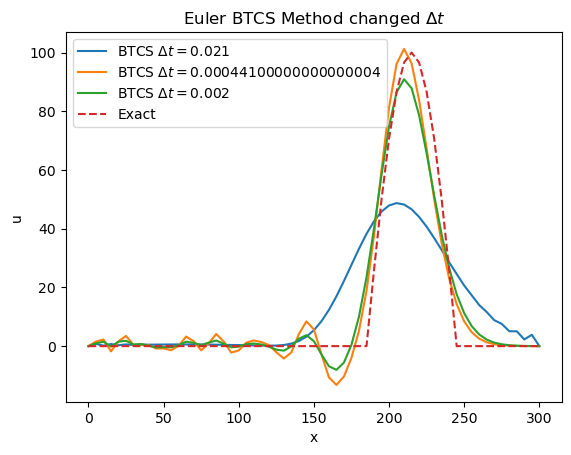

In [29]:
# make btcs more accurate
dt_values = [0.021, (0.021)**2, 0.002]
for dt in dt_values:
    c = (a * dt) / dx
    tstep = int(T/dt) +1
    t_target = 0.45
    times = np.arange(tstep) * dt
    idx = np.argmin(np.abs(times - t_target))
    resultbtcs = btcs(u0, c, tstep)
    print("Courrant number for dt = ", dt,"Courrant: ", c)
    plt.plot(x, resultbtcs[idx, :], label=rf'BTCS $\Delta t = {dt}$')
# exact solution
exact = exact_sol(x, times[idx])
plt.plot(x, exact, '--', label='Exact')
plt.title(r'Euler BTCS Method changed $\Delta t$')
plt.xlabel('x')
plt.ylabel('u')
plt.legend()
plt.savefig('btcs4.png')
plt.show()

# Part 3 Inviscid Burgers Equation

In [52]:
# define parameters for burgers equation
L = 4 
dx = 0.1
xstep = int(L/dx)
x = np.linspace(0, L, xstep)

In [53]:
# define the initial condition for burgers equation 
def initial_burgers(x):
    u0 = np.where(x < 2, 1, 0)
    return u0

In [54]:
# define the exact solution for burgers equation
def exact_burgers(x,t):
    return np.where(x < 2 + t/2, 1, 0)

In [55]:
#calculate errors over time
def calculate_errors_burgers(result, x, tstep, dt, dx):

    L2_inf = np.zeros(tstep)
    L2_error = np.zeros(tstep)

    for t in range(tstep):
        L2_inf[t] = np.max(np.abs(result[t,:] - exact_burgers(x,t*dt)))
        L2_error[t] = np.sqrt(np.sum(np.abs(result[t,:] - exact_burgers(x,t*dt))**2) * dx)
    
    return L2_inf, L2_error

## Lax Method

In [56]:
def lax_burgers(u0, dt, dx, tstep):
    u  = np.zeros((tstep, len(u0)))
    u[0, :] = u0
    for t in range (tstep-1):
        u[t+1, 1:-1] = 0.5*(u[t, 2:] + u[t, :-2]) - dt/(2*dx) * (u[t, 2:]**2/2 - u[t, :-2]**2/2)
        #boundary conditions
        u[t+1, 0]  = 1
        u[t+1, -1] = 0
    return u

$\Delta t = 0.14$

Courrant number:  1.4000000000000001


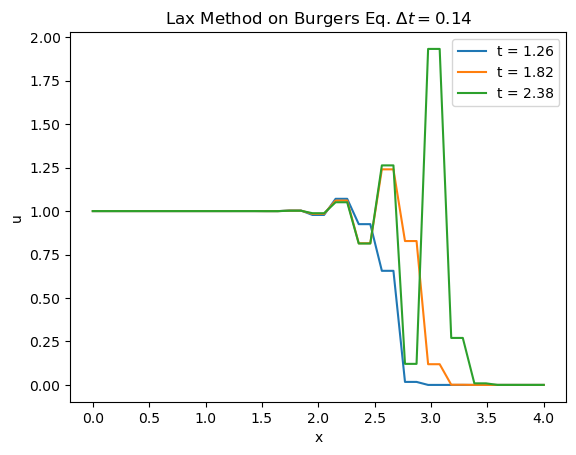

In [57]:
# define changing parameters
dt = 0.14
T= 2.5
t_targets = [1.2, 1.8, 2.4]
c= dt/dx
tstep = int(T/dt) +1
u0 = initial_burgers(x)
times = np.arange(tstep) * dt
print("Courrant number: ", c)

# apply method
result14 = lax_burgers(u0, dt, dx, tstep)

# plot results
for t_target in t_targets:
    idx = np.argmin(np.abs(times - t_target))
    plt.plot(x, result14[idx, :], label=f't = {times[idx]:.2f}')


plt.title(r'Lax Method on Burgers Eq. $\Delta t = 0.14$')
plt.xlabel('x')
plt.ylabel('u')
plt.legend()
plt.savefig('laxburgers1.png')
plt.show()


L_inf error: 1.9328732458981126
L2 error:  1.8795554384540707


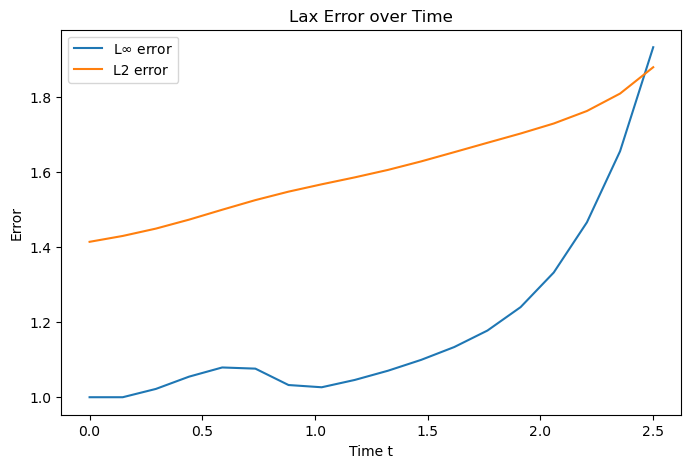

In [59]:
#use the function defined above to calculate the error
L2_inf, L2_error = calculate_errors(result14, x, tstep, dt, dx)
print("L_inf error:", L2_inf[-1])
print("L2 error: ", L2_error[-1])


#plot error over time
plt.figure(figsize=(8,5))
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_inf, label='L$\infty$ error')
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_error, label='L2 error')
plt.xlabel('Time t')
plt.ylabel('Error')
plt.title('Lax Error over Time')
plt.legend()
plt.savefig('laxburgers_error1.png')
plt.show()

$\Delta t = 0.1$

Courrant number:  1.0


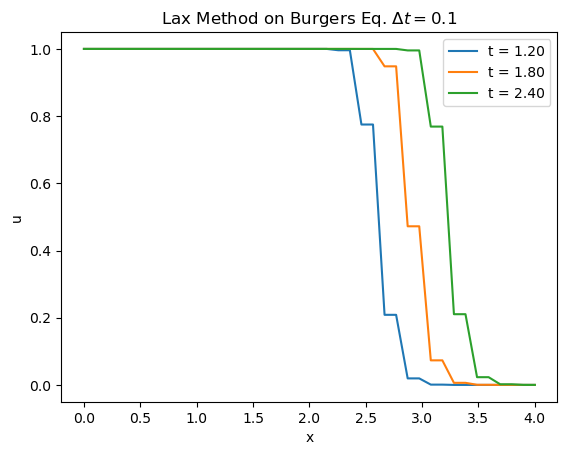

In [37]:
# define changing parameters
dt = 0.1
T= 2.5
t_targets = [1.2, 1.8, 2.4]
c= dt/dx
tstep = int(T/dt) +1
u0 = initial_burgers(x)
times = np.arange(tstep) * dt
print("Courrant number: ", c)

# apply method
result_1 = lax_burgers(u0, dt, dx, tstep)

# plot results
for t_target in t_targets:
    idx = np.argmin(np.abs(times - t_target))
    plt.plot(x, result_1[idx, :], label=f't = {times[idx]:.2f}')

    if t_target == 2.4:
        idx_01_24 = idx


plt.title(r'Lax Method on Burgers Eq. $\Delta t = 0.1$')
plt.xlabel('x')
plt.ylabel('u')
plt.legend()
plt.savefig('laxburgers2.png')
plt.show()

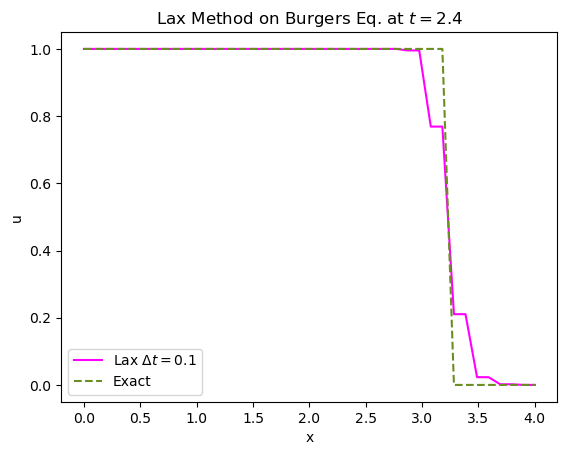

In [38]:
# changing parameters 
exact = exact_burgers(x, times[idx])


#plot results compared to exact sol.
plt.plot(x, result_1[idx_01_24, :], color = 'magenta', label='Lax $\Delta t = 0.1$')
plt.plot(x, exact, '--', color = "olivedrab", label='Exact')
plt.title(r'Lax Method on Burgers Eq. at $t=2.4$')
plt.xlabel('x')
plt.ylabel('u')
plt.legend()
plt.savefig('laxburgers4.png')
plt.show()

L_inf error: 1.0
L2 error:  1.7817695396117346


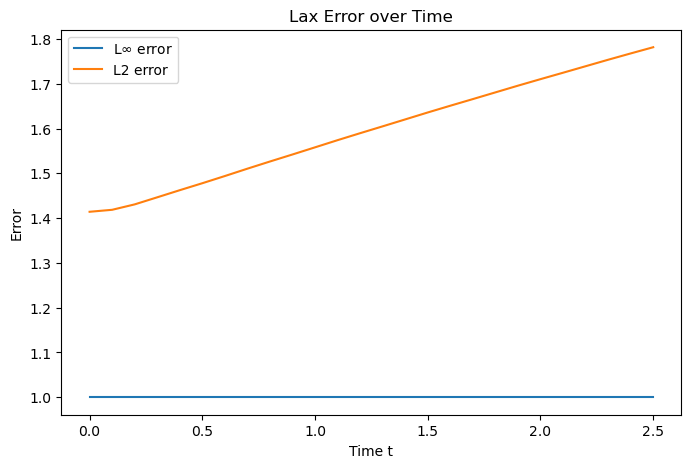

In [39]:
#use the function defined above to calculate the error
L2_inf, L2_error = calculate_errors(result_1, x, tstep, dt, dx)
print("L_inf error:", L2_inf[-1])
print("L2 error: ", L2_error[-1])
#plot error over time
plt.figure(figsize=(8,5))
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_inf, label='L$\infty$ error')
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_error, label='L2 error')
plt.xlabel('Time t')
plt.ylabel('Error')
plt.title('Lax Error over Time')
plt.legend()
plt.savefig('laxburgers_error2.png')
plt.show()

$\Delta t = 0.05$

Courrant number:  0.5


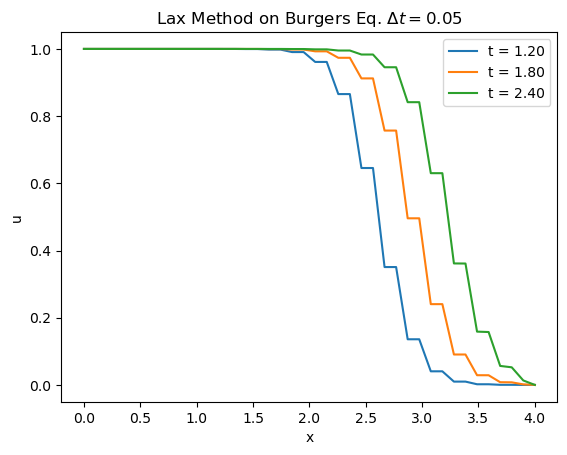

In [40]:
# define changing parameters
dt = 0.05
T= 2.5
t_targets = [1.2, 1.8, 2.4]
c= dt/dx
tstep = int(T/dt) +1
u0 = initial_burgers(x)
times = np.arange(tstep) * dt
print("Courrant number: ", c)

# apply method
result05 = lax_burgers(u0, dt, dx, tstep)

# plot results
for t_target in t_targets:
    idx = np.argmin(np.abs(times - t_target))
    plt.plot(x, result05[idx, :], label=f't = {times[idx]:.2f}')
    if t_target == 2.4:
        idx_05_24 = idx


plt.title(r'Lax Method on Burgers Eq. $\Delta t = 0.05$')
plt.xlabel('x')
plt.ylabel('u')
plt.legend()
plt.savefig('laxburgers3.png')
plt.show()

L_inf error: 1.0
L2 error:  1.7525224161265416


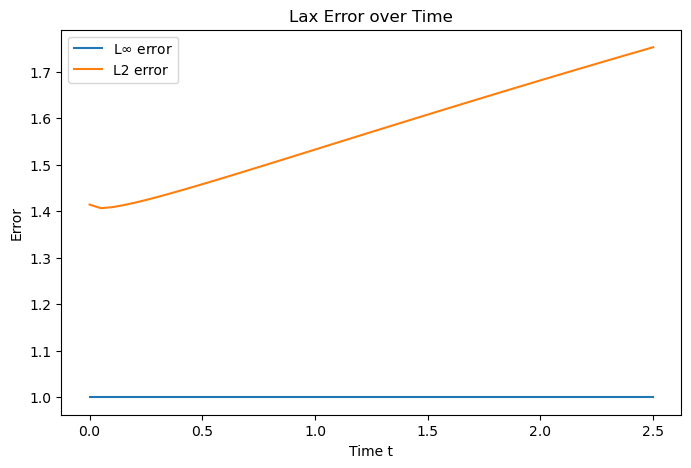

In [41]:
#use the function defined above to calculate the error
L2_inf, L2_error = calculate_errors(result05, x, tstep, dt, dx)
print("L_inf error:", L2_inf[-1])
print("L2 error: ", L2_error[-1])
#plot error over time
plt.figure(figsize=(8,5))
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_inf, label='L$\infty$ error')
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_error, label='L2 error')
plt.xlabel('Time t')
plt.ylabel('Error')
plt.title('Lax Error over Time')
plt.legend()
plt.savefig('laxburgers_error3.png')
plt.show()

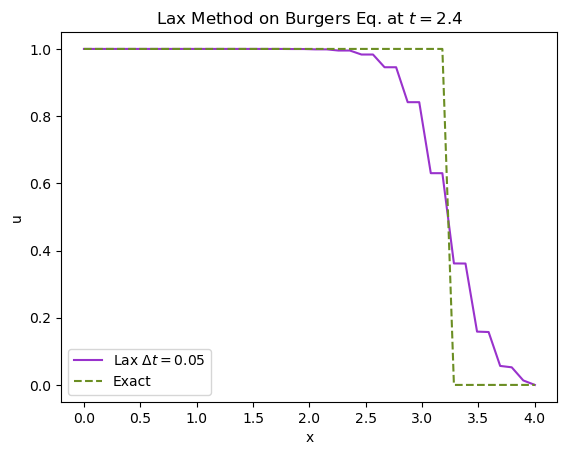

In [42]:
# changing parameters 
exact = exact_burgers(x, times[idx])


#plot results compared to exact sol.
plt.plot(x, result05[idx_05_24, :], color = 'darkorchid', label='Lax $\Delta t = 0.05$')
plt.plot(x, exact, '--', color = "olivedrab", label='Exact')
plt.title(r'Lax Method on Burgers Eq. at $t=2.4$')
plt.xlabel('x')
plt.ylabel('u')
plt.legend()
plt.savefig('laxburgers5.png')
plt.show()

## MacCormack Method

In [43]:
def maccormack(u0, dt, dx, tstep):
    u  = np.zeros((tstep, len(u0)))
    u[0, :] = u0
    for t in range (tstep-1):
        # predictor step
        u_star = u[t, :].copy()
        u_star[1:-1] = u[t, 1:-1] - dt/dx*(u[t, 2:]**2/2 - u[t, 1:-1]**2/2)
        u_star[0]  = 1.0
        u_star[-1] = 0.0
        # corrector step
        u[t+1, 1:-1] = 0.5*(u[t, 1:-1] + u_star[1:-1]) - dt/(2*dx)*(u_star[1:-1]**2/2 - u_star[:-2]**2/2)
        #boundary conditions
        u[t+1, 0]  = 1
        u[t+1, -1] = 0
    return u

$\Delta t = 0.14$

Courrant number:  1.4000000000000001


/tmp/ipykernel_315/3206293389.py:11: RuntimeWarning: overflow encountered in square
  u[t+1, 1:-1] = 0.5*(u[t, 1:-1] + u_star[1:-1]) - dt/(2*dx)*(u_star[1:-1]**2/2 - u_star[:-2]**2/2)
/tmp/ipykernel_315/3206293389.py:11: RuntimeWarning: invalid value encountered in subtract
  u[t+1, 1:-1] = 0.5*(u[t, 1:-1] + u_star[1:-1]) - dt/(2*dx)*(u_star[1:-1]**2/2 - u_star[:-2]**2/2)
/tmp/ipykernel_315/3206293389.py:7: RuntimeWarning: overflow encountered in square
  u_star[1:-1] = u[t, 1:-1] - dt/dx*(u[t, 2:]**2/2 - u[t, 1:-1]**2/2)
/tmp/ipykernel_315/3206293389.py:7: RuntimeWarning: invalid value encountered in subtract
  u_star[1:-1] = u[t, 1:-1] - dt/dx*(u[t, 2:]**2/2 - u[t, 1:-1]**2/2)


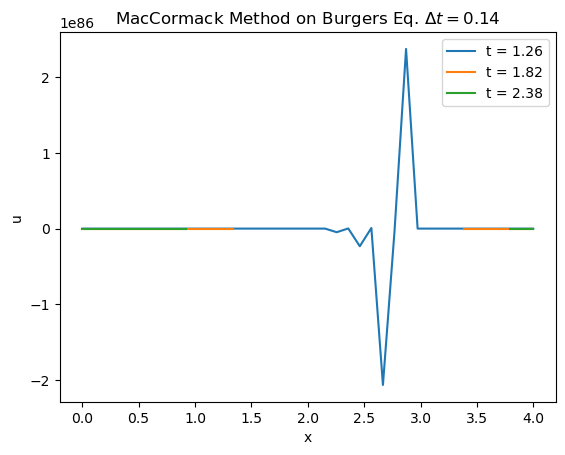

In [44]:
# define changing parameters
dt = 0.14
T= 2.5
t_targets = [1.2, 1.8, 2.4]
c= dt/dx
tstep = int(T/dt) +1
u0 = initial_burgers(x)
times = np.arange(tstep) * dt
print("Courrant number: ", c)

# apply method
result_14 = maccormack(u0, dt, dx, tstep)

# plot results
for t_target in t_targets:
    idx = np.argmin(np.abs(times - t_target))
    plt.plot(x, result_14[idx, :], label=f't = {times[idx]:.2f}')

plt.title(r'MacCormack Method on Burgers Eq. $\Delta t = 0.14$')
plt.xlabel('x')
plt.ylabel('u')
plt.legend()
plt.savefig('mac1.png')
plt.show()

/tmp/ipykernel_315/3772451151.py:9: RuntimeWarning: overflow encountered in square
  L2_error[t] = np.sqrt(np.sum(np.abs(result[t,:] - exact_sol(x,t*dt))**2)*dx)


L_inf error: nan
L2 error:  nan


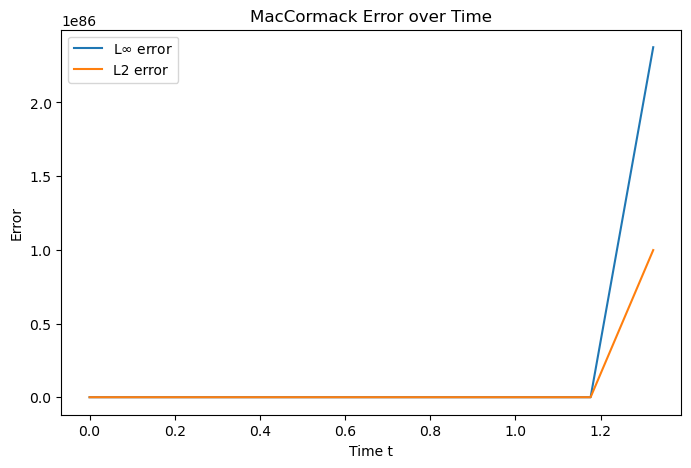

In [45]:
#use the function defined above to calculate the error
L2_inf, L2_error = calculate_errors(result_14, x, tstep, dt, dx)
print("L_inf error:", L2_inf[-1])
print("L2 error: ", L2_error[-1])
#plot error over time
plt.figure(figsize=(8,5))
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_inf, label='L$\infty$ error')
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_error, label='L2 error')
plt.xlabel('Time t')
plt.ylabel('Error')
plt.title('MacCormack Error over Time')
plt.legend()
plt.savefig('mac_error1.png')
plt.show()

$\Delta t = 0.1$

Courrant number:  1.0


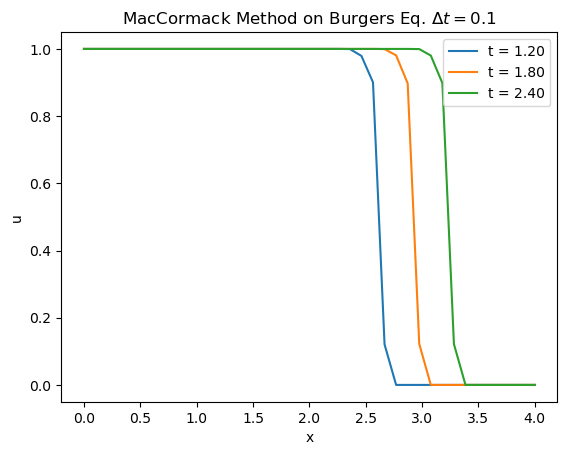

In [46]:
# define changing parameters
dt = 0.1
T= 2.5
t_targets = [1.2, 1.8, 2.4]
c= dt/dx
tstep = int(T/dt) +1
u0 = initial_burgers(x)
times = np.arange(tstep) * dt
print("Courrant number: ", c)

# apply method
result1_ = maccormack(u0, dt, dx, tstep)

# plot results
for t_target in t_targets:
    idx = np.argmin(np.abs(times - t_target))
    plt.plot(x, result1_[idx, :], label=f't = {times[idx]:.2f}')

plt.title(r'MacCormack Method on Burgers Eq. $\Delta t = 0.1$')
plt.xlabel('x')
plt.ylabel('u')
plt.legend()
plt.savefig('mac2.png')
plt.show()

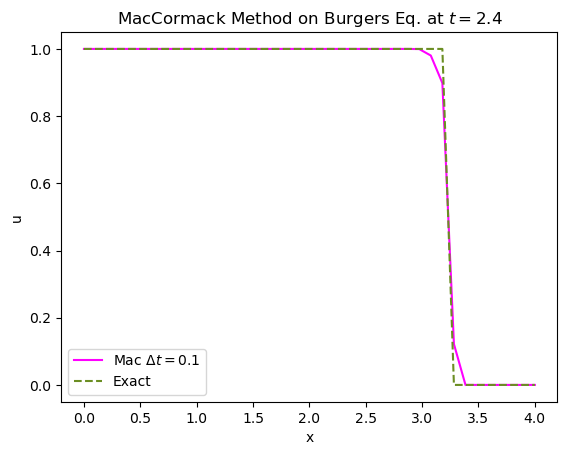

In [47]:
# changing parameters 
exact = exact_burgers(x, times[idx])

#plot results compared to exact sol.
plt.plot(x, result1_[idx, :], color = 'magenta', label='Mac $\Delta t = 0.1$')
plt.plot(x, exact, '--', color = "olivedrab", label='Exact')
plt.title(r'MacCormack Method on Burgers Eq. at $t=2.4$')
plt.xlabel('x')
plt.ylabel('u')
plt.legend()
plt.savefig('mac4.png')
plt.show()

L_inf error: 1.0
L2 error:  1.794572268203129


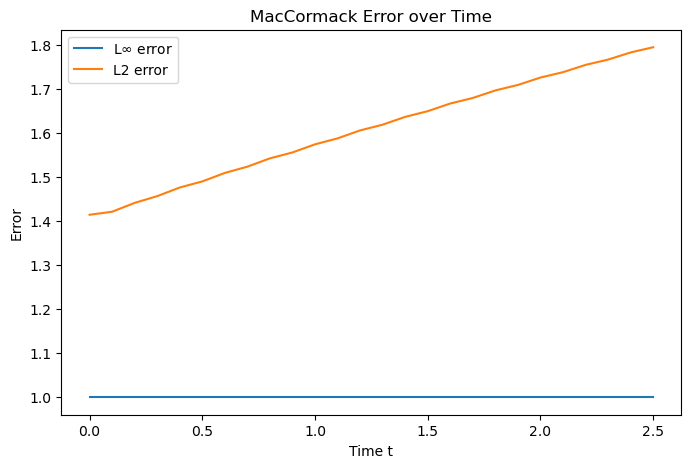

In [48]:
#use the function defined above to calculate the error
L2_inf, L2_error = calculate_errors(result1_, x, tstep, dt, dx)
print("L_inf error:", L2_inf[-1])
print("L2 error: ", L2_error[-1])
#plot error over time
plt.figure(figsize=(8,5))
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_inf, label='L$\infty$ error')
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_error, label='L2 error')
plt.xlabel('Time t')
plt.ylabel('Error')
plt.title('MacCormack Error over Time')
plt.legend()
plt.savefig('mac_error2.png')
plt.show()

$ \Delta t = 0.05$

Courrant number:  0.5


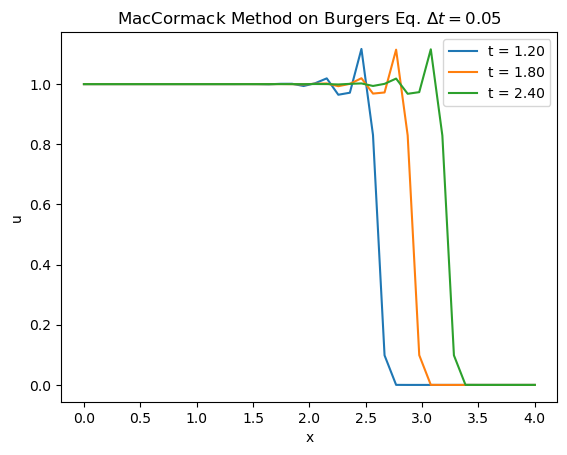

In [49]:
# define changing parameters
dt = 0.05
T= 2.5
t_targets = [1.2, 1.8, 2.4]
c= dt/dx
tstep = int(T/dt) +1
u0 = initial_burgers(x)
times = np.arange(tstep) * dt
print("Courrant number: ", c)
# apply method
result_05 = maccormack(u0, dt, dx, tstep)

# plot results
for t_target in t_targets:
    idx = np.argmin(np.abs(times - t_target))
    plt.plot(x, result_05[idx, :], label=f't = {times[idx]:.2f}')


plt.title(r'MacCormack Method on Burgers Eq. $\Delta t = 0.05$')
plt.xlabel('x')
plt.ylabel('u')
plt.legend()
plt.savefig('mac3.png')
plt.show()

L_inf error: 1.079654700551257
L2 error:  1.7985272081747532


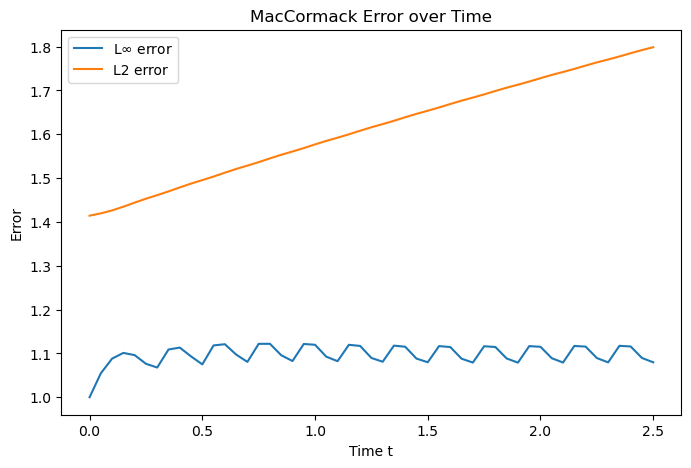

In [50]:
#use the function defined above to calculate the error
L2_inf, L2_error = calculate_errors(result_05, x, tstep, dt, dx)
print("L_inf error:", L2_inf[-1])
print("L2 error: ", L2_error[-1])
#plot error over time
plt.figure(figsize=(8,5))
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_inf, label='L$\infty$ error')
plt.plot(np.linspace(0, T, int(T/dt)+1), L2_error, label='L2 error')
plt.xlabel('Time t')
plt.ylabel('Error')
plt.title('MacCormack Error over Time')
plt.legend()
plt.savefig('mac_error3.png')
plt.show()

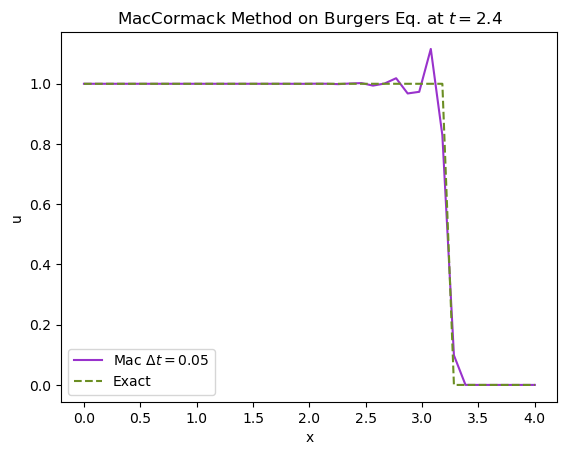

In [51]:
# changing parameters 
exact = exact_burgers(x, times[idx])


#plot results compared to exact sol.
plt.plot(x, result_05[idx, :], color = 'darkorchid', label='Mac $\Delta t = 0.05$')
plt.plot(x, exact, '--', color = "olivedrab", label='Exact')
plt.title(r'MacCormack Method on Burgers Eq. at $t=2.4$')
plt.xlabel('x')
plt.ylabel('u')
plt.legend()
plt.savefig('mac5.png')
plt.show()